In [2]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import folium

pd.options.display.max_columns = None

REPO_ROOT = Path.cwd().parent
DATA_DIR = REPO_ROOT / "data"

In [24]:
total_count = pd.read_parquet(DATA_DIR / "bronze" / "prf_accidents" / "br=101").shape[0]

In [25]:
sc_acc = pd.read_parquet(DATA_DIR / "bronze" / "prf_accidents" / "br=101").query("uf == 'SC'")
sc_acc["latitude"] = sc_acc["latitude"].astype(str).str.replace(",", ".").astype(float)
sc_acc["longitude"] = sc_acc["longitude"].astype(str).str.replace(",", ".").astype(float)
sc_acc["geometry"] = gpd.points_from_xy(sc_acc["longitude"], sc_acc["latitude"])
sc_acc = gpd.GeoDataFrame(sc_acc, geometry="geometry", crs="EPSG:4326")
sc_count = sc_acc.shape[0]
sc_acc.head()

,id,data_inversa,dia_semana,horario,uf,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,source_year_file,geometry
5,257,2017-01-01,domingo,18:40:00,SC,"98,5",BALNEARIO PICARRAS,Falta de Atenção à Condução,Capotamento,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Dupla,Reta,Não,5,0,2,1,1,1,3,4,-26.744188,-48.696638,SPRF-SC,DEL03-SC,UOP02-DEL03-SC,2017,POINT (-48.69664 -26.74419)
7,334,2017-01-02,segunda-feira,01:05:00,SC,"106,5",PENHA,Condutor Dormindo,Tombamento,Com Vítimas Fatais,Plena Noite,Crescente,Nublado,Dupla,Reta,Não,3,1,0,0,0,3,0,4,-26.814747,-48.683360,SPRF-SC,DEL03-SC,UOP02-DEL03-SC,2017,POINT (-48.68336 -26.81475)
10,449,2017-01-02,segunda-feira,12:30:00,SC,129,BALNEARIO CAMBORIU,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,Pleno dia,Decrescente,Sol,Dupla,Reta,Sim,3,0,1,0,2,0,1,3,-26.981268,-48.676686,SPRF-SC,DEL04-SC,UOP03-DEL04-SC,2017,POINT (-48.67669 -26.98127)
13,644,2017-01-03,terça-feira,02:55:00,SC,"334,1",TUBARAO,Animais na Pista,Atropelamento de Animal,Sem Vítimas,Plena Noite,Crescente,Nublado,Dupla,Curva,Sim,1,0,0,0,1,0,0,1,-28.465618,-49.009838,SPRF-SC,DEL02-SC,UOP01-DEL02-SC,2017,POINT (-49.00984 -28.46562)
14,645,2017-01-03,terça-feira,02:55:00,SC,"334,1",TUBARAO,Animais na Pista,Atropelamento de Animal,Sem Vítimas,Plena Noite,Crescente,Nublado,Dupla,Curva,Sim,1,0,0,0,1,0,0,1,-28.467539,-49.008003,SPRF-SC,DEL02-SC,UOP01-DEL02-SC,2017,POINT (-49.008 -28.46754)


In [26]:
sc_percentage = sc_count / total_count * 100
print(f"Total accidents in Brazil: {total_count}")
print(f"Total accidents in Santa Catarina: {sc_count}")
print(f"Percentage of accidents in Santa Catarina: {sc_percentage:.2f}%")

Total accidents in Brazil: 108618
Total accidents in Santa Catarina: 37957
Percentage of accidents in Santa Catarina: 34.95%


In [18]:
sc_acc

,id,data_inversa,dia_semana,horario,uf,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,source_year_file,geometry
5,257,2017-01-01,domingo,18:40:00,SC,"98,5",BALNEARIO PICARRAS,Falta de Atenção à Condução,Capotamento,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Dupla,Reta,Não,5,0,2,1,1,1,3,4,-26.744188,-48.696638,SPRF-SC,DEL03-SC,UOP02-DEL03-SC,2017,POINT (-48.69664 -26.74419)
7,334,2017-01-02,segunda-feira,01:05:00,SC,"106,5",PENHA,Condutor Dormindo,Tombamento,Com Vítimas Fatais,Plena Noite,Crescente,Nublado,Dupla,Reta,Não,3,1,0,0,0,3,0,4,-26.814747,-48.683360,SPRF-SC,DEL03-SC,UOP02-DEL03-SC,2017,POINT (-48.68336 -26.81475)
10,449,2017-01-02,segunda-feira,12:30:00,SC,129,BALNEARIO CAMBORIU,Falta de Atenção à Condução,Colisão traseira,Com Vítimas Feridas,Pleno dia,Decrescente,Sol,Dupla,Reta,Sim,3,0,1,0,2,0,1,3,-26.981268,-48.676686,SPRF-SC,DEL04-SC,UOP03-DEL04-SC,2017,POINT (-48.67669 -26.98127)
13,644,2017-01-03,terça-feira,02:55:00,SC,"334,1",TUBARAO,Animais na Pista,Atropelamento de Animal,Sem Vítimas,Plena Noite,Crescente,Nublado,Dupla,Curva,Sim,1,0,0,0,1,0,0,1,-28.465618,-49.009838,SPRF-SC,DEL02-SC,UOP01-DEL02-SC,2017,POINT (-49.00984 -28.46562)
14,645,2017-01-03,terça-feira,02:55:00,SC,"334,1",TUBARAO,Animais na Pista,Atropelamento de Animal,Sem Vítimas,Plena Noite,Crescente,Nublado,Dupla,Curva,Sim,1,0,0,0,1,0,0,1,-28.467539,-49.008003,SPRF-SC,DEL02-SC,UOP01-DEL02-SC,2017,POINT (-49.008 -28.46754)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108586,755407,2026-02-13,sexta-feira,10:20:00,SC,157,PORTO BELO,Ausência de reação do condutor,Colisão lateral sentido oposto,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Reta,Sim,2,0,1,0,0,1,1,2,-27.182845,-48.612046,SPRF-SC,DEL04-SC,UOP03-DEL04-SC,2026,POINT (-48.61205 -27.18284)
108594,756457,2026-02-23,segunda-feira,06:00:00,SC,144,ITAPEMA,Ausência de reação do condutor,Colisão com objeto,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Dupla,Curva,Sim,1,0,1,0,0,0,1,1,-27.066146,-48.595787,SPRF-SC,DEL04-SC,UOP03-DEL04-SC,2026,POINT (-48.59579 -27.06615)
108608,757882,2026-01-15,quinta-feira,18:00:00,SC,206,SAO JOSE,Manobra de mudança de faixa,Queda de ocupante de veículo,Com Vítimas Feridas,Pleno dia,Crescente,Ignorado,Múltipla,Reta,Sim,2,0,1,0,1,0,1,2,-27.588512,-48.617031,SPRF-SC,DEL01-SC,UOP01-DEL01-SC,2026,POINT (-48.61703 -27.58851)
108609,758228,2026-02-18,quarta-feira,20:30:00,SC,"243,4",PALHOCA,Ausência de reação do condutor,Colisão lateral mesmo sentido,Com Vítimas Feridas,Plena Noite,Crescente,Nublado,Dupla,Reta,Sim,2,0,1,0,1,0,1,2,-27.887623,-48.647944,SPRF-SC,DEL01-SC,UOP02-DEL01-SC,2026,POINT (-48.64794 -27.88762)


<Axes: >

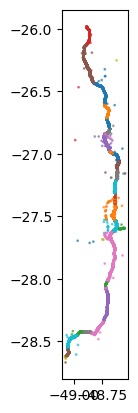

In [22]:
# Remove outliers on both tails (lower and upper) for latitude and longitude using IQR
lat_q1, lat_q3 = sc_acc["latitude"].quantile([0.25, 0.75])
lon_q1, lon_q3 = sc_acc["longitude"].quantile([0.25, 0.75])

lat_iqr = lat_q3 - lat_q1
lon_iqr = lon_q3 - lon_q1

lat_min, lat_max = lat_q1 - 1.5 * lat_iqr, lat_q3 + 1.5 * lat_iqr
lon_min, lon_max = lon_q1 - 1.5 * lon_iqr, lon_q3 + 1.5 * lon_iqr

sc_acc_no_outliers = sc_acc[
    sc_acc["latitude"].between(lat_min, lat_max)
    & sc_acc["longitude"].between(lon_min, lon_max)
]

sc_acc_no_outliers.plot(
    column="municipio",
    markersize=1,
    alpha=0.6,
    categorical=True,
    legend=False,
)


In [31]:
m = folium.Map(location=[sc_acc_no_outliers["latitude"].mean(), sc_acc_no_outliers["longitude"].mean()], zoom_start=8)

for _, row in sc_acc_no_outliers.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        color="blue",
        fill=True,
        fill_opacity=0.5,
    ).add_to(m)

m.save("sc_accidents_map.html")

In [33]:
sc_acc_no_outliers.municipio.nunique()

34

In [34]:
sc_acc_no_outliers.municipio.value_counts()

municipio
SAO JOSE                     6254
PALHOCA                      4600
ITAJAI                       3344
BALNEARIO CAMBORIU           2871
JOINVILLE                    2683
BIGUACU                      2521
ITAPEMA                      1868
TUBARAO                      1460
BARRA VELHA                  1104
IMBITUBA                     1089
ARAQUARI                      983
PORTO BELO                    721
LAGUNA                        592
GARUVA                        568
TIJUCAS                       552
BALNEARIO PICARRAS            548
PAULO LOPES                   541
PENHA                         494
CAPIVARI DE BAIXO             428
PESCARIA BRAVA                325
JAGUARUNA                     249
NAVEGANTES                    187
CAMBORIU                      164
GAROPABA                      118
GOVERNADOR CELSO RAMOS         85
FLORIANOPOLIS                  53
SANGAO                         45
TREZE DE MAIO                  18
SANTO AMARO DA IMPERATRIZ       4
GUAR

In [5]:
sc_ref = pd.read_parquet(DATA_DIR / "gold" / "br101_sc_municipio_panel" / "canonical_accidents_by_municipio")

In [6]:
sc_ref

,id,timestamp,data_inversa,horario,month,quarter,week_start,uf,municipio,br,dia_semana,fase_dia,condicao_metereologica,tipo_acidente,classificacao_acidente,pessoas,mortos,fatal_victims_occ,has_fatality_occ,codigo_municipio,nome_municipio,depends_on_tolerant_geometry,year
0,9,2017-01-01 00:01:00,2017-01-01,00:01:00,1,1,2016-12-26,SC,PALHOCA,101,domingo,Plena Noite,Chuva,Colisão com objeto estático,Sem Vítimas,1.0,0.0,0.0,False,4211900,Palhoça,False,2017
1,23,2017-01-01 01:38:00,2017-01-01,01:38:00,1,1,2016-12-26,SC,BIGUACU,101,domingo,Plena Noite,Chuva,Saída de leito carroçável,Com Vítimas Feridas,1.0,0.0,0.0,False,4202305,Biguaçu,False,2017
2,24,2017-01-01 02:10:00,2017-01-01,02:10:00,1,1,2016-12-26,SC,JOINVILLE,101,domingo,Plena Noite,Chuva,Colisão traseira,Com Vítimas Feridas,2.0,0.0,0.0,False,4209102,Joinville,False,2017
3,36,2017-01-01 03:00:00,2017-01-01,03:00:00,1,1,2016-12-26,SC,PALHOCA,101,domingo,Plena Noite,Céu Claro,Incêndio,Sem Vítimas,1.0,0.0,0.0,False,4211900,Palhoça,False,2017
4,57,2017-01-01 06:05:00,2017-01-01,06:05:00,1,1,2016-12-26,SC,PORTO BELO,101,domingo,Pleno dia,Nublado,Saída de leito carroçável,Com Vítimas Feridas,1.0,0.0,0.0,False,4213500,Porto Belo,False,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37751,755296,2026-02-28 15:45:00,2026-02-28,15:45:00,2,1,2026-02-23,SC,SAO JOAO DO SUL,101,sábado,Pleno dia,Céu Claro,Tombamento,Com Vítimas Feridas,2.0,0.0,0.0,False,4216404,São João do Sul,False,2026
37752,755287,2026-02-28 17:20:00,2026-02-28,17:20:00,2,1,2026-02-23,SC,IMBITUBA,101,sábado,Pleno dia,Céu Claro,Atropelamento de Pedestre,Com Vítimas Feridas,2.0,0.0,0.0,False,4207304,Imbituba,False,2026
37753,755278,2026-02-28 17:30:00,2026-02-28,17:30:00,2,1,2026-02-23,SC,PALHOCA,101,sábado,Pleno dia,Céu Claro,Colisão com objeto,Com Vítimas Feridas,1.0,0.0,0.0,False,4211900,Palhoça,False,2026
37754,755318,2026-02-28 20:00:00,2026-02-28,20:00:00,2,1,2026-02-23,SC,BALNEARIO PICARRAS,101,sábado,Plena Noite,Céu Claro,Saída de leito carroçável,Com Vítimas Feridas,1.0,0.0,0.0,False,4212809,Balneário Piçarras,False,2026


In [9]:
sc_mun = pd.read_parquet(DATA_DIR / "gold" / "br101_sc_municipio_panel" / "municipios_in_scope")

In [13]:
from shapely import wkt

sc_mun_enriched = sc_mun.copy()
sc_mun_enriched["geometry"] = sc_mun_enriched["geometry"].apply(wkt.loads)
sc_mun_enriched = gpd.GeoDataFrame(sc_mun_enriched, geometry="geometry", crs="EPSG:4674")

if isinstance(sc_mun_enriched.geometry.iloc[0], str):
    sc_mun_enriched["geometry"] = gpd.GeoSeries.from_wkt(sc_mun_enriched["geometry"], crs="EPSG:4674")
    sc_mun_enriched = gpd.GeoDataFrame(sc_mun_enriched, geometry="geometry", crs="EPSG:4674")

centroids = (
    sc_mun_enriched.to_crs(sc_mun_enriched.estimate_utm_crs())
    .geometry.centroid
    .to_crs(sc_mun_enriched.crs)
)

sc_mun_enriched["centroid"] = centroids
sc_mun_enriched["centroid_lat"] = centroids.y
sc_mun_enriched["centroid_lon"] = centroids.x
centroid_copy_paste = "\n".join(
    f"{lat:.5f},{lon:.5f}"
    for lat, lon in zip(sc_mun_enriched["centroid_lat"], sc_mun_enriched["centroid_lon"])
)

print(centroid_copy_paste)


-26.46168,-48.75777
-28.94234,-49.47116
-27.00473,-48.62175
-26.66243,-48.72738
-27.43352,-48.69396
-27.07093,-48.70897
-28.45556,-48.94339
-28.71568,-49.37971
-28.04672,-48.65893
-26.05713,-48.86731
-27.37661,-48.57723
-28.75167,-49.27737
-28.19424,-48.70266
-26.96899,-48.75338
-27.10858,-48.63442
-28.65788,-49.04467
-26.24429,-48.95142
-28.48638,-48.82589
-28.86396,-49.45554
-26.82875,-48.72742
-27.77176,-48.66172
-29.26724,-49.72193
-27.96483,-48.76015
-26.80776,-48.65076
-28.40176,-48.88364
-26.75949,-48.73330
-27.17480,-48.61643
-28.65131,-49.12583
-29.12148,-49.74376
-29.20556,-49.81347
-27.57847,-48.65625
-29.07019,-49.65593
-27.24755,-48.70092
-28.56622,-49.15418
-28.48158,-49.03727


In [7]:
date_series = pd.to_datetime(sc_ref["data_inversa"])
week_series = pd.to_datetime(sc_ref["week_start"])

municipios = sorted(sc_ref["municipio"].dropna().unique())
all_dates = pd.date_range(date_series.min(), date_series.max(), freq="D")
all_weeks = pd.date_range(week_series.min(), week_series.max(), freq="W-MON")

daily_counts = (
    sc_ref.assign(data_inversa=date_series)
    .groupby(["municipio", "data_inversa"])
    .size()
    .reindex(
        pd.MultiIndex.from_product(
            [municipios, all_dates], names=["municipio", "data_inversa"]
        ),
        fill_value=0,
    )
    .rename("daily_accidents")
    .reset_index()
)

weekly_counts = (
    sc_ref.assign(week_start=week_series)
    .groupby(["municipio", "week_start"])
    .size()
    .reindex(
        pd.MultiIndex.from_product(
            [municipios, all_weeks], names=["municipio", "week_start"]
        ),
        fill_value=0,
    )
    .rename("weekly_accidents")
    .reset_index()
)

municipio_accident_stats = (
    sc_ref.groupby("municipio")
    .size()
    .rename("total_accidents")
    .to_frame()
    .join(
        daily_counts.groupby("municipio")["daily_accidents"].agg(
            daily_min="min",
            daily_max="max",
            daily_mean="mean",
            daily_median="median",
        )
    )
    .join(
        weekly_counts.groupby("municipio")["weekly_accidents"].agg(
            weekly_min="min",
            weekly_max="max",
            weekly_mean="mean",
            weekly_median="median",
        )
    )
    .reset_index()
    .sort_values("total_accidents", ascending=False)
)

municipio_accident_stats

,municipio,total_accidents,daily_min,daily_max,daily_mean,daily_median,weekly_min,weekly_max,weekly_mean,weekly_median
35,SAO JOSE,6237,0,13,1.864017,2.0,0,33,13.020877,13.0
24,PALHOCA,4592,0,7,1.372385,1.0,1,20,9.586639,9.0
16,ITAJAI,3316,0,6,0.991034,1.0,0,17,6.922756,7.0
2,BALNEARIO CAMBORIU,2861,0,5,0.855051,1.0,0,16,5.972860,6.0
19,JOINVILLE,2674,0,6,0.799163,1.0,0,15,5.582463,5.0
5,BIGUACU,2512,0,6,0.750747,0.0,0,14,5.244259,5.0
17,ITAPEMA,1863,0,6,0.556784,0.0,0,14,3.889353,4.0
39,TUBARAO,1453,0,6,0.434250,0.0,0,10,3.033403,3.0
4,BARRA VELHA,1100,0,4,0.328751,0.0,0,9,2.296451,2.0
15,IMBITUBA,1089,0,4,0.325463,0.0,0,8,2.273486,2.0
